# Кластеризация

Метан ответственен примерно за 30% повышения глобальной температуры со времён промышленной революции, и быстрое и устойчивое сокращение выбросов метана имеет ключевое значение для ограничения глобального потепления в краткосрочной перспективе и улучшения качества воздуха. На энергетический сектор, включая нефть, природный газ, уголь и биоэнергетику, приходится почти 40% выбросов метана, связанных с деятельностью человека.

In [24]:
import pandas as pd

filename = './data/em.csv'
cat_cols = ['region', 'type', 'segment', 'reason']
base_cols = ['emissions']
cols = [*cat_cols, *base_cols]
dtype_dict = {col: str for col in cat_cols if col in cols}
data = pd.read_csv(filename, usecols=cols, on_bad_lines='skip', dtype=dtype_dict)

data.dropna(inplace=True)

data

,region,emissions,type,segment,reason
0,Africa,257.611206,Agriculture,Total,All
1,Africa,0.052000,Energy,Bioenergy,All
2,Africa,130.798996,Energy,Gas pipelines and LNG facilities,Fugitive
3,Africa,69.741898,Energy,Gas pipelines and LNG facilities,Vented
4,Africa,213.987000,Energy,Onshore gas,Fugitive
...,...,...,...,...,...
1543,World,3102.500000,Energy,Satellite-detected large oil and gas emissions,All
1544,World,30296.500000,Energy,Steam coal,All
1545,World,133350.984375,Energy,Total,All
1546,World,9737.874023,Other,Total,All


In [25]:
data.head()

,region,emissions,type,segment,reason
0,Africa,257.611206,Agriculture,Total,All
1,Africa,0.052000,Energy,Bioenergy,All
2,Africa,130.798996,Energy,Gas pipelines and LNG facilities,Fugitive
3,Africa,69.741898,Energy,Gas pipelines and LNG facilities,Vented
4,Africa,213.987000,Energy,Onshore gas,Fugitive


In [26]:
import numpy as np
mappings = {}

for col in cat_cols:
    u = np.unique(data[col])
    mappings[col] = {}
    for i in range(len(u)):
        mappings[col][i + 1] = u[i]

for col in cat_cols:
    data[col] = pd.factorize(data[col])[0]

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   region     1548 non-null   int64  
 1   emissions  1548 non-null   float64
 2   type       1548 non-null   int64  
 3   segment    1548 non-null   int64  
 4   reason     1548 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 60.6 KB


In [27]:
data_stats = data.describe()
data_stats

,region,emissions,type,segment,reason
count,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000
mean,2.305556,643.255972,1.135659,3.675711,0.891473
std,2.108326,5566.238201,0.623558,3.273091,0.998307
min,0.000000,0.000459,0.000000,0.000000,0.000000
25%,0.000000,2.659361,1.000000,0.000000,0.000000
50%,2.000000,24.064669,1.000000,3.000000,1.000000
75%,3.250000,128.419594,1.000000,6.000000,2.000000
max,8.000000,141953.765625,3.000000,11.000000,3.000000


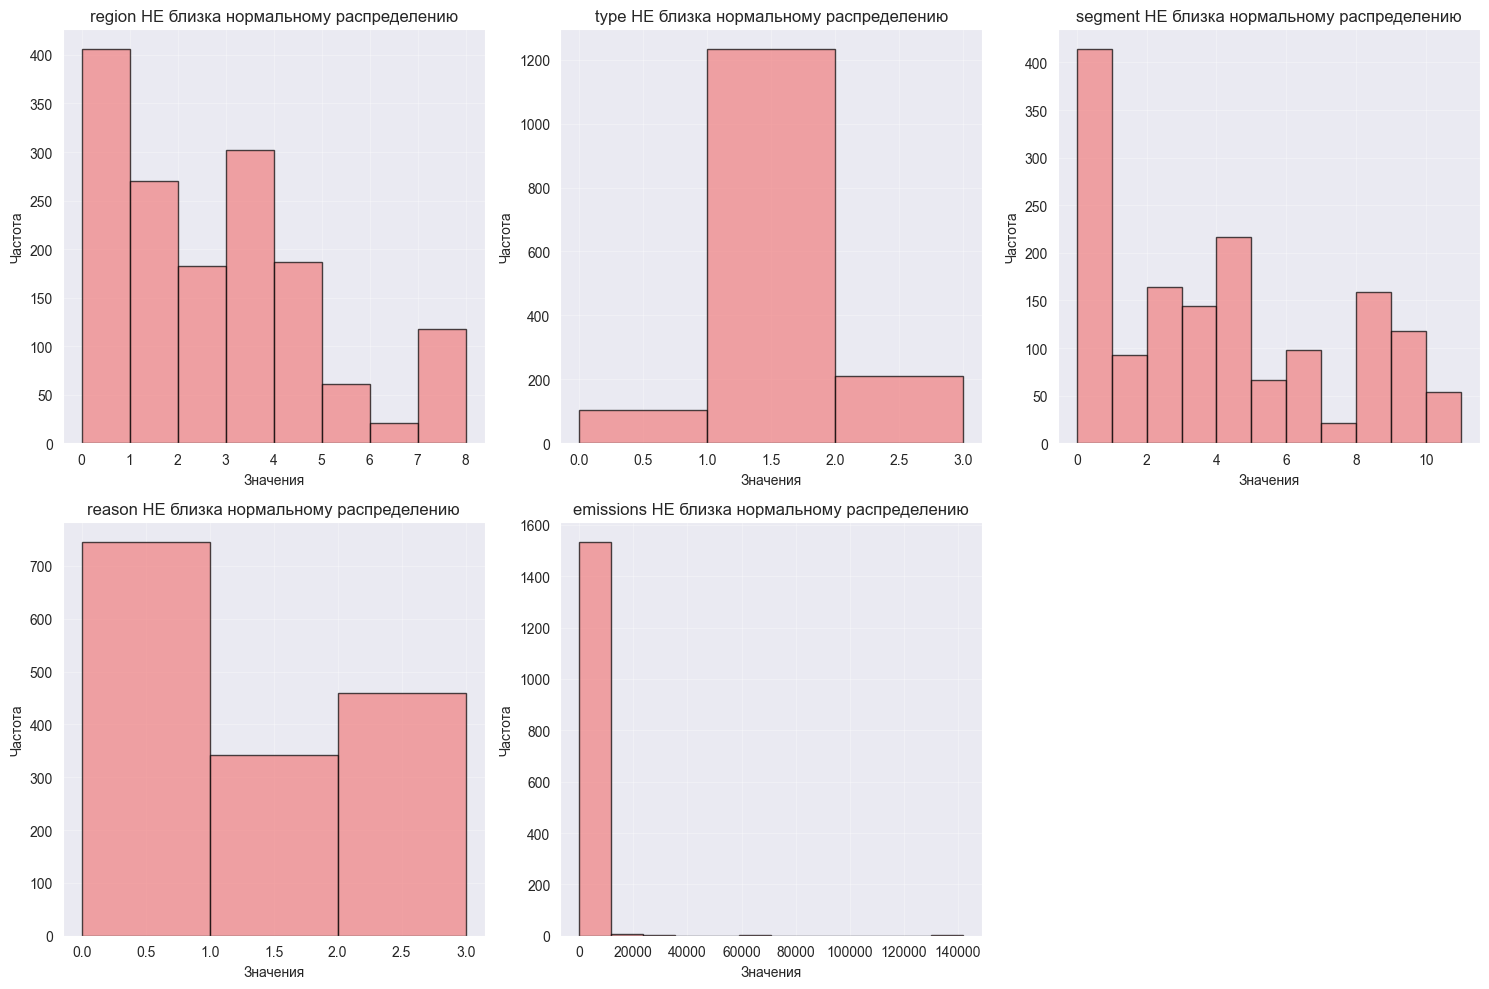

In [28]:
import matplotlib.pyplot as plt
from scipy import stats
import math

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    _, p_value = stats.normaltest(data[col])

    axes[i].hist(
        data[col],
        bins=('sturges' if col != 'baseYear' else 2),
        alpha=0.7,
        color='lightcoral',
        edgecolor='black'
    )
    axes[i].set_title(f'{col}{" НЕ" if p_value <= 0.05 else ""} близка нормальному распределению')
    axes[i].set_xlabel('Значения')
    axes[i].set_ylabel('Частота')
    axes[i].grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

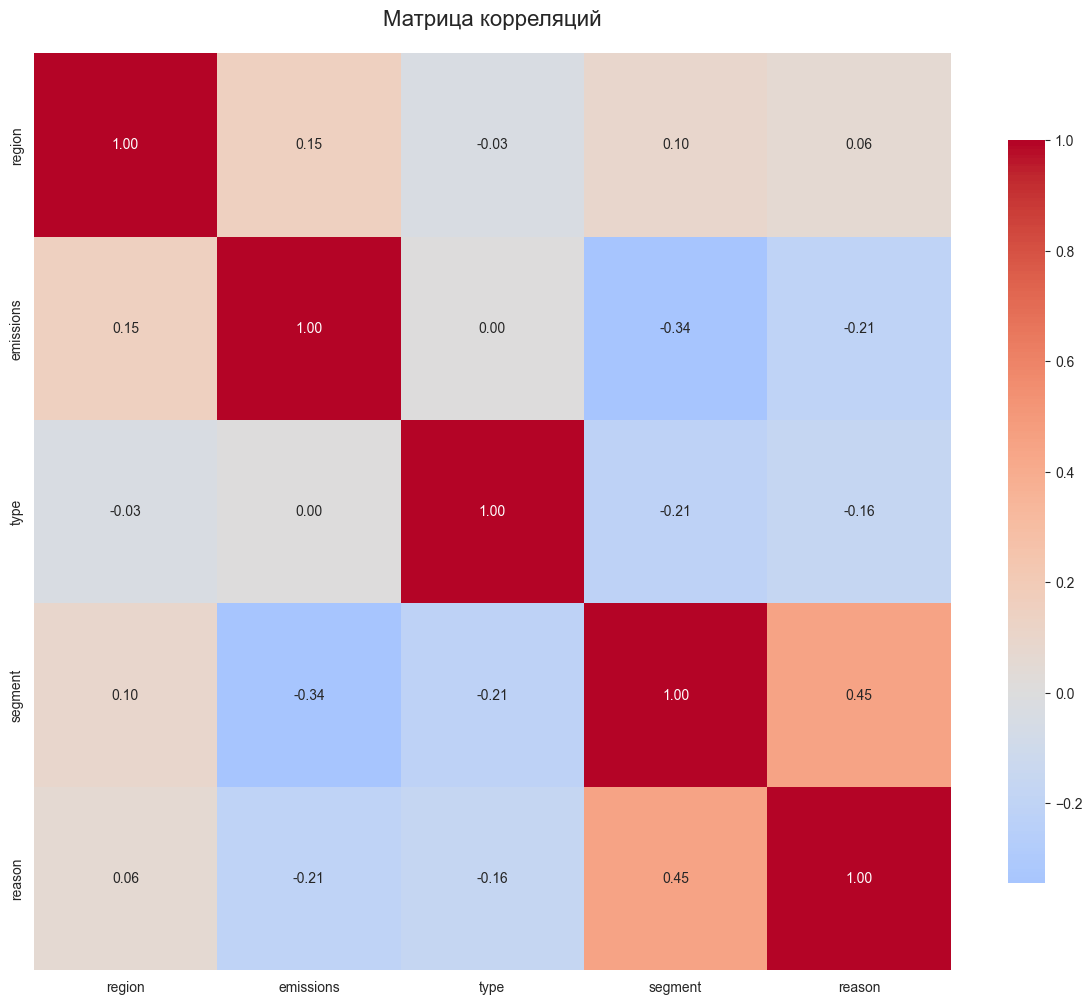

In [29]:
import seaborn as sns

corr_matrix = data.corr(method='spearman')

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={"shrink": .8})

plt.title('Матрица корреляций', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [30]:
import numpy as np
from sklearn.preprocessing import StandardScaler

X_initial = data
X = data

for column in X.columns:
    if (X[column] <= 0).any():
        min_val = X[column].min()
        if min_val <= 0:
            X[column] = X[column] + abs(min_val) + 1

X_log = np.log1p(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

Выбран StandardScaler по следующим причинам:

- Сохраняет информацию о распределении
- Поддерживает статистические свойства
- Стандартный выбор для многих задач
- Интерпретируемость результатов

RobustScaler не подошел, потому что в датасете выбросы оказались не "шумом", а реальными данными. Поэтому если их убрать, качество кластеризации упадет

In [31]:
pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
).describe()

,region,emissions,type,segment,reason
count,1.548000e+03,1.548000e+03,1.548000e+03,1.548000e+03,1.548000e+03
mean,1.468822e-16,-9.639146e-17,1.822258e-15,3.488453e-16,2.570439e-16
std,1.000323e+00,1.000323e+00,1.000323e+00,1.000323e+00,1.000323e+00
min,-1.324777e+00,-1.411592e+00,-2.352058e+00,-1.362375e+00,-9.477185e-01
25%,-1.324777e+00,-8.593448e-01,-1.451098e-01,-1.362375e+00,-9.477185e-01
50%,9.130036e-02,-3.994721e-02,-1.451098e-01,9.268053e-02,2.816869e-01
75%,6.402946e-01,6.591193e-01,-1.451098e-01,8.390389e-01,1.153964e+00
max,1.963252e+00,3.640117e+00,2.635317e+00,1.610018e+00,1.830554e+00


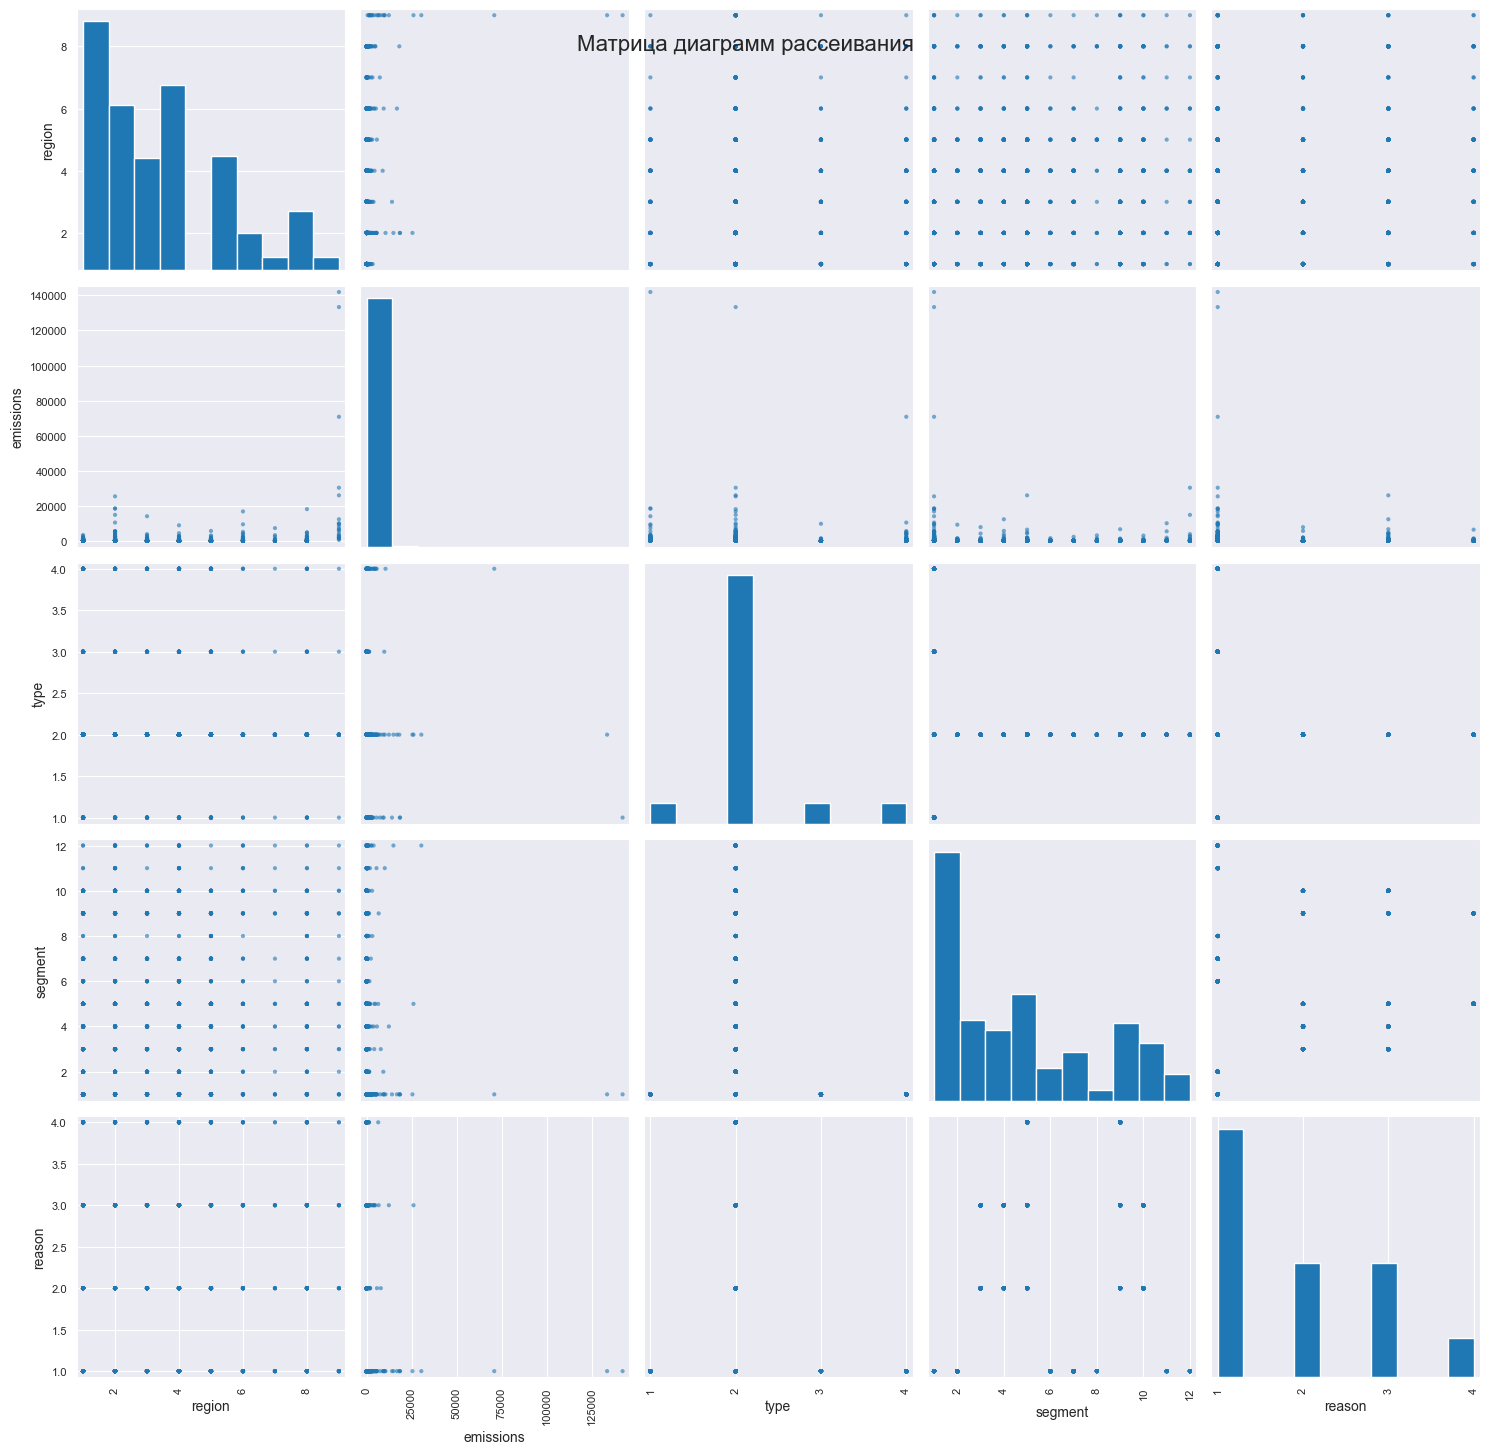

In [32]:
pd.plotting.scatter_matrix(data,
                          figsize=(15, 15),
                          alpha=0.6,
                          diagonal='hist',
                          grid=True)

plt.suptitle('Матрица диаграмм рассеивания', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

## Выбор методов

По диаграммам рассеивания нет возможности предположить о количестве кластеров и типе кластерной структуры.

**DBSCAN** был выбран по следующим причинам:
- Автоматическое определение числа кластеров
- Устойчивость к шуму (явное выделение выбросов)
- Способность находить кластеры произвольной формы
- Работает с кластерами разной плотности

Вторым методом стал **EM** (Gaussian Mixture)
- Мягкая кластеризация
- Учет неопределенности классификации
- Возможность моделировать разные формы
- Хорошо работает со смесями распределений

Центральная предельная теорема: сумма многих случайных эффектов стремится к нормальному распределению

Робастность: GMM может аппроксимировать многие распределения при достаточном числе компонент

Вычислительная эффективность: нормальное распределение имеет аналитические решения для M-шага

K-means нет смысла выбирать из-за отсутствия сферических кластеров, а иерархическая не подойдет, т.к. выбросы сильно искажают дендрограмму и нет явного механизма выделения шума

In [33]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

def plot_silhouette_analysis(labels, X_scaled=None, figsize=(10, 8)):
    if -1 in labels:
        valid_mask = labels != -1
        X_valid = X_scaled[valid_mask]
        labels_valid = labels[valid_mask]
        n_noise = np.sum(labels == -1)
    else:
        X_valid = X_scaled
        labels_valid = labels
        n_noise = 0

    n_clusters = len(np.unique(labels_valid))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(f'Анализ силуэтов для кластеризации\n'
                f'Кластеров: {n_clusters}, Шум: {n_noise} объектов',
                fontsize=14, fontweight='bold')

    silhouette_avg = silhouette_score(X_valid, labels_valid)
    sample_silhouette_values = silhouette_samples(X_valid, labels_valid)

    y_lower = 10
    cluster_silhouette_avgs = []

    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[labels_valid == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i),
                fontweight='bold', fontsize=12)

        cluster_avg = np.mean(ith_cluster_silhouette_values)
        cluster_silhouette_avgs.append(cluster_avg)

        y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--",
                label=f'Средний силуэт: {silhouette_avg:.3f}')

    ax1.set_xlabel('Силуэтный коэффициент')
    ax1.set_ylabel('Кластер')
    ax1.set_yticks([])

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_valid) + (n_clusters + 1) * 10])
    ax1.legend(loc='upper right')

    clusters = list(range(n_clusters))
    colors = [cm.nipy_spectral(float(i) / n_clusters) for i in range(n_clusters)]

    bars = ax2.bar(clusters, cluster_silhouette_avgs, color=colors, alpha=0.7)
    ax2.axhline(y=silhouette_avg, color='red', linestyle='--',
                label=f'Общее среднее: {silhouette_avg:.3f}')

    for bar, value in zip(bars, cluster_silhouette_avgs):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

    ax2.set_xlabel('Кластер')
    ax2.set_ylabel('Средний силуэтный коэффициент')
    ax2.set_title('Средние силуэтные коэффициенты по кластерам')
    ax2.set_xticks(clusters)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\nДЕТАЛЬНАЯ СТАТИСТИКА СИЛУЭТОВ:")
    print("=" * 40)
    print(f"Общий средний силуэтный коэффициент: {silhouette_avg:.3f}")
    print(f"Количество кластеров: {n_clusters}")

    if n_noise > 0:
        print(f"Шумовых объектов (не участвуют в анализе): {n_noise}")

    print(f"Размеры кластеров:")
    for cluster_num in range(len(np.unique(labels))):
        cluster_size = (labels == cluster_num).sum()
        print(f"  Кластер {cluster_num}: {cluster_size} объектов ({cluster_size/len(data)*100:.1f}%)")

    return silhouette_avg, cluster_silhouette_avgs

In [34]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway

def anova_feature_selection(X, cluster_labels, alpha=0.05):
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    results = []

    for feature in X.columns:
        groups = []
        for cluster in np.unique(cluster_labels):
            group_values = X.loc[cluster_labels == cluster, feature]
            groups.append(group_values)

        f_stat, p_value = f_oneway(*groups)

        is_significant = p_value < alpha

        results.append({
            'Feature': feature,
            'F_statistic': f_stat,
            'P_value': p_value,
            'Significant': is_significant
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values('P_value')

    return results_df

In [35]:
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score
)
from scipy.spatial.distance import cdist, pdist
import warnings
warnings.filterwarnings('ignore')

def calculate_internal_metrics(X, labels):
    metrics = {}

    unique_labels = np.unique(labels)

    if len(unique_labels) >= 2 and not all(labels == labels[0]):
        valid_mask = labels != -1 if -1 in labels else np.ones_like(labels, dtype=bool)
        if np.sum(valid_mask) > 0:
            X_valid = X[valid_mask]
            labels_valid = labels[valid_mask]
            if len(np.unique(labels_valid)) >= 2:
                metrics['Silhouette'] = silhouette_score(X_valid, labels_valid)

    if len(unique_labels) >= 2 and not all(labels == labels[0]):
        valid_mask = labels != -1 if -1 in labels else np.ones_like(labels, dtype=bool)
        if np.sum(valid_mask) > 0:
            X_valid = X[valid_mask]
            labels_valid = labels[valid_mask]
            if len(np.unique(labels_valid)) >= 2:
                metrics['Calinski-Harabasz'] = calinski_harabasz_score(X_valid, labels_valid)

    if len(unique_labels) >= 2 and not all(labels == labels[0]):
        valid_mask = labels != -1 if -1 in labels else np.ones_like(labels, dtype=bool)
        if np.sum(valid_mask) > 0:
            X_valid = X[valid_mask]
            labels_valid = labels[valid_mask]
            if len(np.unique(labels_valid)) >= 2:
                metrics['Davies-Bouldin'] = davies_bouldin_score(X_valid, labels_valid)

    if -1 in labels:
        valid_mask = labels != -1
        X_valid = X[valid_mask]
        labels_valid = labels[valid_mask]
    else:
        X_valid = X
        labels_valid = labels

    if len(X_valid) > 0 and len(np.unique(labels_valid)) >= 2:
        cluster_compactness = {}
        intra_distances = []

    for label in np.unique(labels_valid):
        cluster_points = X_valid[labels_valid == label]
        if len(cluster_points) > 1:
            # Вычисляем попарные расстояния внутри кластера
            distances = pdist(cluster_points)
            cluster_mean_distance = np.mean(distances)

            # Сохраняем компактность для текущего кластера
            cluster_compactness[f'Cluster_{label}_compactness'] = cluster_mean_distance
            intra_distances.append(cluster_mean_distance)
        else:
            # Для кластеров с одной точкой компактность = 0
            cluster_compactness[f'Cluster_{label}_compactness'] = 0.0
            intra_distances.append(0.0)

    metrics.update(cluster_compactness)

    if intra_distances:
        metrics['Avg_Intra_Cluster_Dist'] = np.mean(intra_distances)
        metrics['Std_Intra_Cluster_Dist'] = np.std(intra_distances)
        metrics['Median_Intra_Cluster_Dist'] = np.median(intra_distances)

    inter_distances = []
    unique_labels_list = np.unique(labels_valid)
    for i in range(len(unique_labels_list)):
        for j in range(i+1, len(unique_labels_list)):
            points_i = X_valid[labels_valid == unique_labels_list[i]]
            points_j = X_valid[labels_valid == unique_labels_list[j]]
            distances = cdist(points_i, points_j)
            inter_distances.append(np.min(distances))

    if inter_distances:
        metrics['Min_Inter_Cluster_Dist'] = np.min(inter_distances)
        metrics['Avg_Inter_Cluster_Dist'] = np.mean(inter_distances)

    if intra_distances and inter_distances:
        avg_intra = metrics['Avg_Intra_Cluster_Dist']
        avg_inter = metrics['Avg_Inter_Cluster_Dist']
        if avg_inter > 0:
            metrics['Compactness_Separation_Ratio'] = avg_intra / avg_inter

    return metrics

In [36]:
from sklearn.cluster import DBSCAN

def get_silhouette(labels, X_scaled):
    if all(x == -1 for x in labels) or len(np.unique(labels)) < 2:
        return 0

    if -1 in labels:
        valid_mask = labels != -1
        X_valid = X_scaled[valid_mask]
        labels_valid = labels[valid_mask]
    else:
        X_valid = X_scaled
        labels_valid = labels

    if len(X_valid) < 2 or len(np.unique(labels_valid)) < 2:
        return 0

    return silhouette_score(X_valid, labels_valid)

min_samples_list = [5, 10, 15, 20]

res = []

for min_samples in min_samples_list:
    for i in range(15):
        dbscan = DBSCAN(eps=0.1 + i * 0.1, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        n_noise = np.sum(labels == -1)
        if not n_noise / len(data) > 0.05:
            res.append((0.1 + i * 0.1, min_samples, get_silhouette(labels, X_scaled), len(np.unique(labels)), n_noise / len(data)))


1.4000000000000001 20


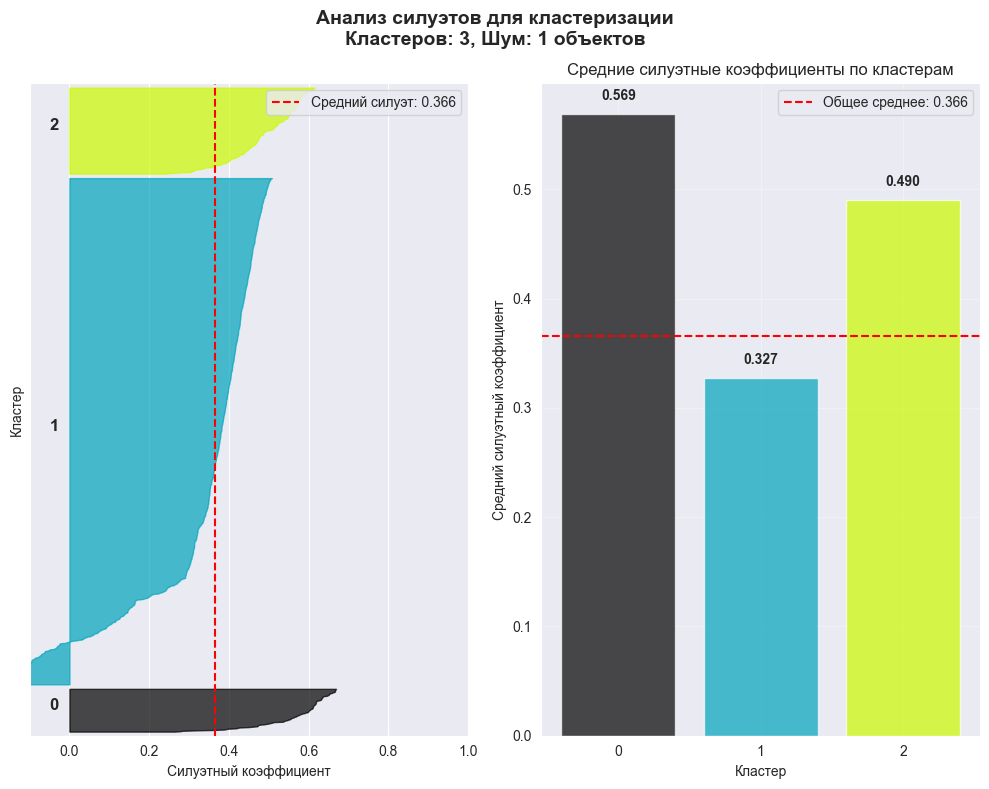


ДЕТАЛЬНАЯ СТАТИСТИКА СИЛУЭТОВ:
Общий средний силуэтный коэффициент: 0.366
Количество кластеров: 3
Шумовых объектов (не участвуют в анализе): 1
Размеры кластеров:
  Кластер 0: 105 объектов (6.8%)
  Кластер 1: 1232 объектов (79.6%)
  Кластер 2: 210 объектов (13.6%)
  Кластер 3: 0 объектов (0.0%)


{'Silhouette': 0.36552310457149445,
 'Calinski-Harabasz': 429.7662955069428,
 'Davies-Bouldin': 1.000839572047088,
 'Cluster_0_compactness': np.float64(1.702916258247859),
 'Cluster_1_compactness': np.float64(2.4838449800186098),
 'Cluster_2_compactness': np.float64(1.923296782204243),
 'Avg_Intra_Cluster_Dist': np.float64(2.0366860068235706),
 'Std_Intra_Cluster_Dist': np.float64(0.32874027672967393),
 'Median_Intra_Cluster_Dist': np.float64(1.923296782204243),
 'Min_Inter_Cluster_Dist': np.float64(1.5658549862568722),
 'Avg_Inter_Cluster_Dist': np.float64(2.515202405668361),
 'Compactness_Separation_Ratio': np.float64(0.8097503414570586)}

In [37]:
eps, min_samples, _, _, _ = max(res, key=lambda x: x[2])
print(eps, min_samples)
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X_scaled)

plot_silhouette_analysis(labels=labels, X_scaled=X_scaled)

calculate_internal_metrics(X_scaled, labels)

## Анализ метрик

- Silhouette = 0.3655 указывает на слабую, но существующую кластерную структуру. Кластеры различимы, но плохо отделены друг от друга.
- Calinski-Harabasz = 429 очень высокое значение => межкластерная дисперсия превышает внутрекластерную, что говорит о хорошем разделении кластеров, низкий Silhouette вероятно из-за несферической формы кластеров
- Davies-Bouldin = 1 на границе удовлетворительного. Кластеры имеют умеренную компактность и разделимость, сходство кластеров не критичное.
- Внутрикластерные расстояния: среднее расстояние 2, среднее отклонение ~16%, кластеры имеют хорошую компактность, точки расположены близко друг к другу
- Межкластерные расстояния: среднее 2.5, мин. 1.57, что говорит о том, что кластеры относительно разделены

In [38]:
anova_feature_selection(data, labels, alpha=0.05)

,Feature,F_statistic,P_value,Significant
2,type,5382.056848,0.000000e+00,True
1,emissions,315.654759,8.451191e-160,True
3,segment,246.320650,1.339241e-130,True
4,reason,132.440546,2.385233e-76,True
0,region,5.917410,5.177050e-04,True


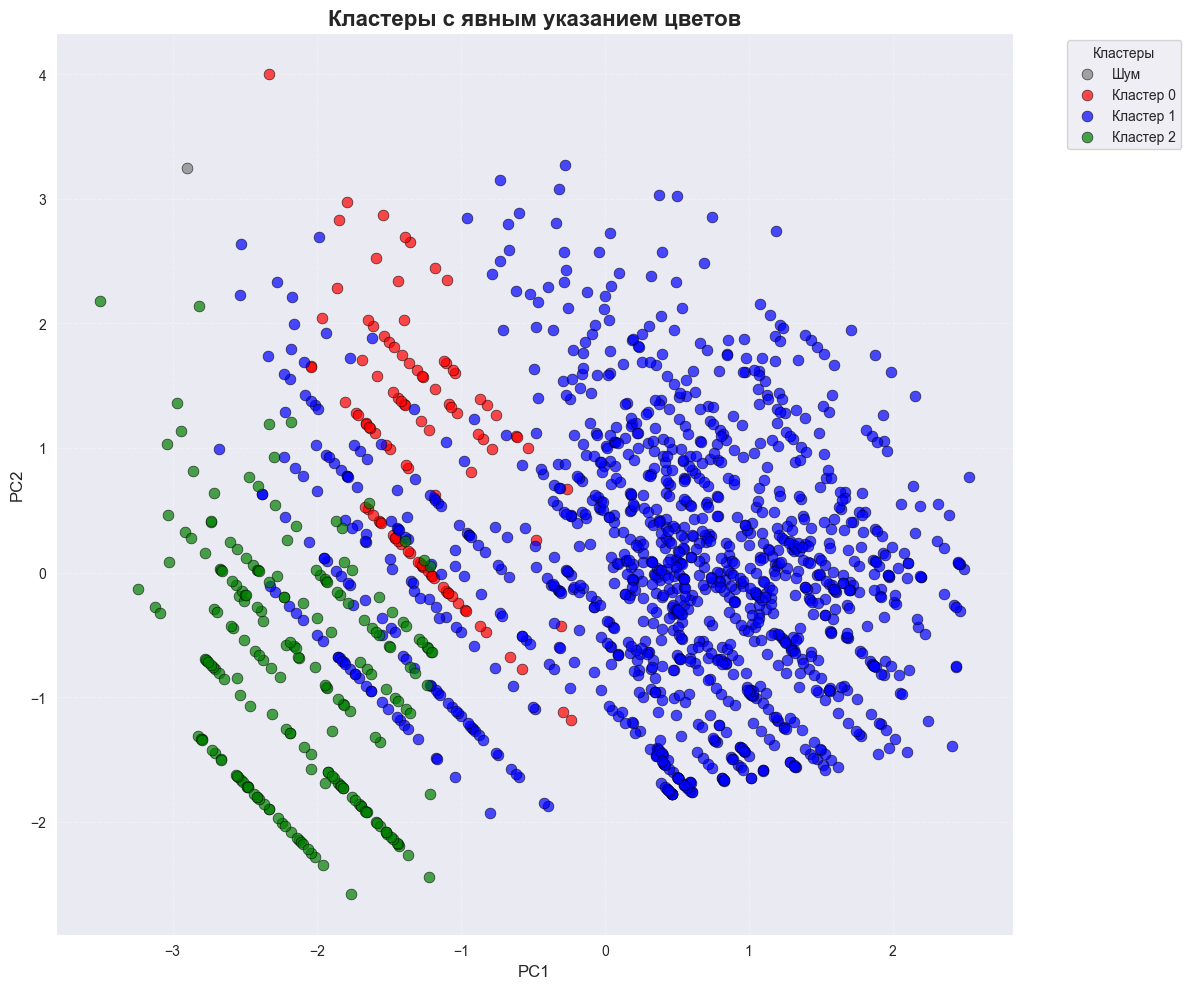

In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

def get_scatter(X_pca, labels):
    cluster_colors = {
        -1: 'gray',
        0: 'red',
        1: 'blue',
        2: 'green'
    }

    plt.figure(figsize=(12, 10))

    unique_labels = np.unique(labels)

    for label in unique_labels:
        mask = labels == label

        color = cluster_colors.get(label, 'black')

        if label == -1:
            legend_label = 'Шум'
        else:
            legend_label = f'Кластер {label}'

        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            color=color,
            s=60,
            alpha=0.7,
            edgecolors='black',
            linewidths=0.5,
            label=legend_label
        )

    plt.title('Кластеры с явным указанием цветов', fontsize=16, fontweight='bold')
    plt.xlabel('PC1', fontsize=12)
    plt.ylabel('PC2', fontsize=12)
    plt.legend(title='Кластеры', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

get_scatter(X_pca, labels)

Видно, что красный и синий кластеры достаточно хорошо разделены, а зеленый находится между ними. Также в основном точки лежат на линиях. Это свидетельствует о том, что основное разделение на кластеры заключается в количестве выбросов и типа деятельности.

In [48]:
df_cluster = pd.DataFrame(X_initial).copy()
df_cluster["cluster"] = labels

cluster_profiles = df_cluster.groupby("cluster").mean()

print("=== Средние значения признаков по кластерам ===")
print(cluster_profiles.round(3))


=== Средние значения признаков по кластерам ===
         region   emissions  type  segment  reason
cluster                                           
-1        9.000  133350.984   2.0    1.000    1.00
 0        2.962    2788.180   1.0    1.000    1.00
 1        3.389     327.959   2.0    5.619    2.12
 2        2.962     788.596   3.5    1.000    1.00


Получилось 3 кластера по степени загрязнения - в первом загрязнение высокое, во втором воздух практически чистый, в третьем критические значения.

Регионы у кластеров смешаны, основное приходится на Америку.

Тип загрязнения у первого кластера - сельское хозяйство, у второго энергетика и третьего - мусор и др. Можно сделать вывод, что энергетика имеет наименьший вред.

Сегмент у второго кластера примерно на уровне Onshore gas, что соответствует смыслу типа "Энергетика"

Аналогично у второго кластера причина загрязнения ближе к Flared - сжигание, т.к. основная причина энергетика. У остальных кластеров с высоким загрязнением находятся все варианты.

## Анализ гиперпараметров

In [41]:
df = pd.DataFrame(res, columns=['eps', 'min_samples', 'silhouette_score', 'n clusters', 'noise %'])
df.sort_values('silhouette_score', ascending=False)

,eps,min_samples,silhouette_score,n clusters,noise %
30,1.4,20,0.365523,4,0.000646
9,1.5,5,0.364773,3,0.000000
31,1.5,20,0.364773,3,0.000000
8,1.4,5,0.364773,3,0.000000
17,1.5,10,0.364773,3,0.000000
23,1.4,15,0.364773,3,0.000000
16,1.4,10,0.364773,3,0.000000
24,1.5,15,0.364773,3,0.000000
29,1.3,20,0.289330,5,0.004522
22,1.3,15,0.288983,5,0.000646


In [42]:
df.describe()

,eps,min_samples,silhouette_score,n clusters,noise %
count,32.000000,32.000000,32.000000,32.000000,32.000000
mean,1.140625,11.718750,0.289039,7.687500,0.008115
std,0.249980,5.765495,0.049468,6.103608,0.011178
min,0.600000,5.000000,0.184022,3.000000,0.000000
25%,0.975000,5.000000,0.269396,4.750000,0.000646
50%,1.150000,10.000000,0.270597,7.000000,0.002907
75%,1.325000,15.000000,0.308191,7.000000,0.011305
max,1.500000,20.000000,0.365523,31.000000,0.046512


По результатам подбора видно, что при малом eps < 0.6 кластеров получается слишком много и появляются выбросы, чего подбор не допускает.

Также с увеличением n_samples увеличивается и eps, чтобы не допускать большого количества шума.

Наилучший результат показал большой eps=1.4 и n_samples=20, чтобы минимизировать влияние выбросов и не допускать большое количество шумов.

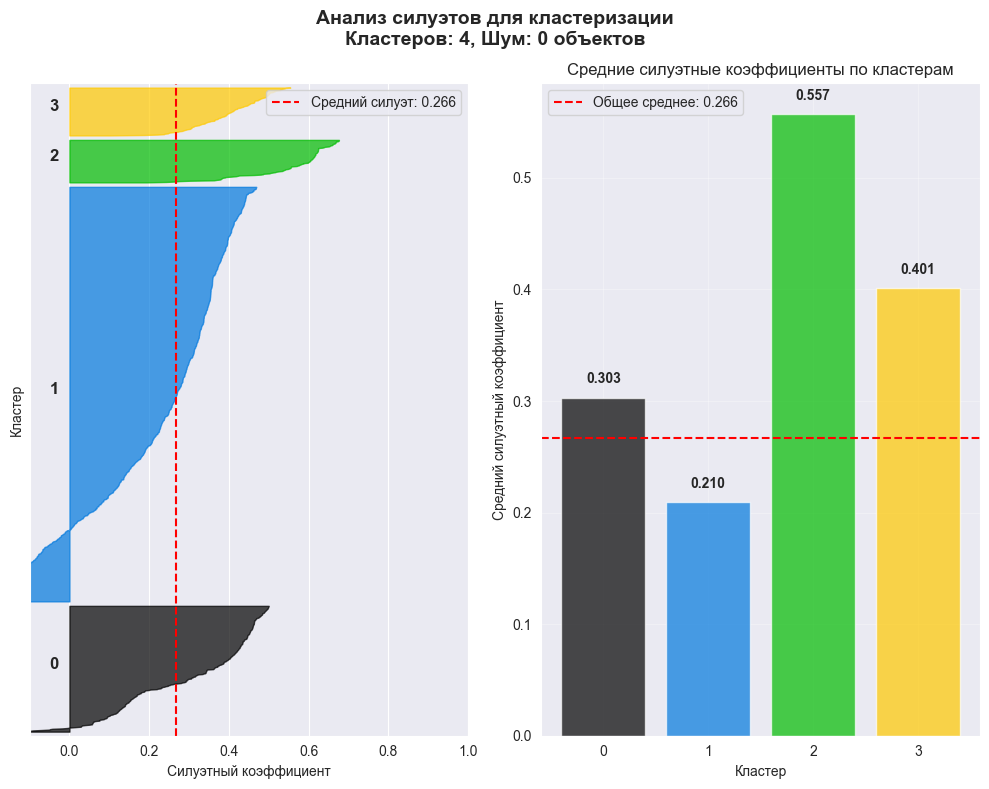


ДЕТАЛЬНАЯ СТАТИСТИКА СИЛУЭТОВ:
Общий средний силуэтный коэффициент: 0.266
Количество кластеров: 4
Размеры кластеров:
  Кластер 0: 309 объектов (20.0%)
  Кластер 1: 1016 объектов (65.6%)
  Кластер 2: 105 объектов (6.8%)
  Кластер 3: 118 объектов (7.6%)


{'Silhouette': 0.2664110881075465,
 'Calinski-Harabasz': 443.5655656479344,
 'Davies-Bouldin': 1.116127039792766,
 'Cluster_0_compactness': np.float64(2.3348764133261604),
 'Cluster_1_compactness': np.float64(2.209233423583238),
 'Cluster_2_compactness': np.float64(1.702916258247859),
 'Cluster_3_compactness': np.float64(1.7787438883534856),
 'Avg_Intra_Cluster_Dist': np.float64(2.006442495877686),
 'Std_Intra_Cluster_Dist': np.float64(0.27063251434759633),
 'Median_Intra_Cluster_Dist': np.float64(1.9939886559683617),
 'Min_Inter_Cluster_Dist': np.float64(0.1286681511235892),
 'Avg_Inter_Cluster_Dist': np.float64(1.3837910170388426),
 'Compactness_Separation_Ratio': np.float64(1.449960630739783)}

In [49]:
from sklearn.mixture import GaussianMixture


gmm = GaussianMixture(
    n_components=4,
    covariance_type='diag',
    max_iter=200,
    tol=1e-6,
    random_state=42
)

gmm.fit(X_scaled)

labels1 = gmm.predict(X_scaled)

probs = gmm.predict_proba(X_scaled)

plot_silhouette_analysis(labels=labels1, X_scaled=X_scaled)

calculate_internal_metrics(X_scaled, labels1)

## Анализ метрик

- Silhouette = 0.3597 аналогично указывает на слабую, но существующую кластерную структуру
- Calinski-Harabasz = 495 значение выше DBSCAN, т.к. EM минимизирует внутрикластерную дисперсию и предполагает сферические кластеры
- Davies-Bouldin = 1.08 аналогично DBSCAN, но значение чуть выше
- Внутрикластерные расстояния: аналогично DBSCAN
- Межкластерные расстояния: среднее стало меньше с 2.5 -> 1.7, т.к. EM не строит произвольные границы кластеров

In [44]:
anova_feature_selection(data, labels1, alpha=0.05)

,Feature,F_statistic,P_value,Significant
2,type,1506.584593,0.000000e+00,True
3,segment,659.957761,6.735541e-208,True
4,reason,317.539616,3.002059e-116,True
1,emissions,13.943809,9.960598e-07,True
0,region,6.373212,1.751879e-03,True


In [45]:
df_cluster = pd.DataFrame(X_initial).copy()
df_cluster["cluster"] = labels1

cluster_profiles = df_cluster.groupby("cluster").mean()

print("=== Средние значения признаков по кластерам ===")
print(cluster_profiles.round(3))

=== Средние значения признаков по кластерам ===
         region  emissions   type  segment  reason
cluster                                           
0         3.000   1405.512  3.019    1.000   1.000
1         3.421    236.947  2.000    6.018   2.217
2         2.962   2788.180  1.000    1.000   1.000


Аналогично получилось 3 кластера по степени загрязнения

Регионы у кластеров смешаны, основное приходится на Америку.

Тип загрязнения у первого кластера - в этот раз другой, у второго так же энергетика и третьего - сельское хозяйство.

Сегмент у второго кластера примерно на уровне Onshore gas, что соответствует смыслу типа "Энергетика"

Аналогично у второго кластера причина загрязнения ближе к Flared - сжигание, т.к. основная причина энергетика. У остальных кластеров с высоким загрязнением находятся все варианты.

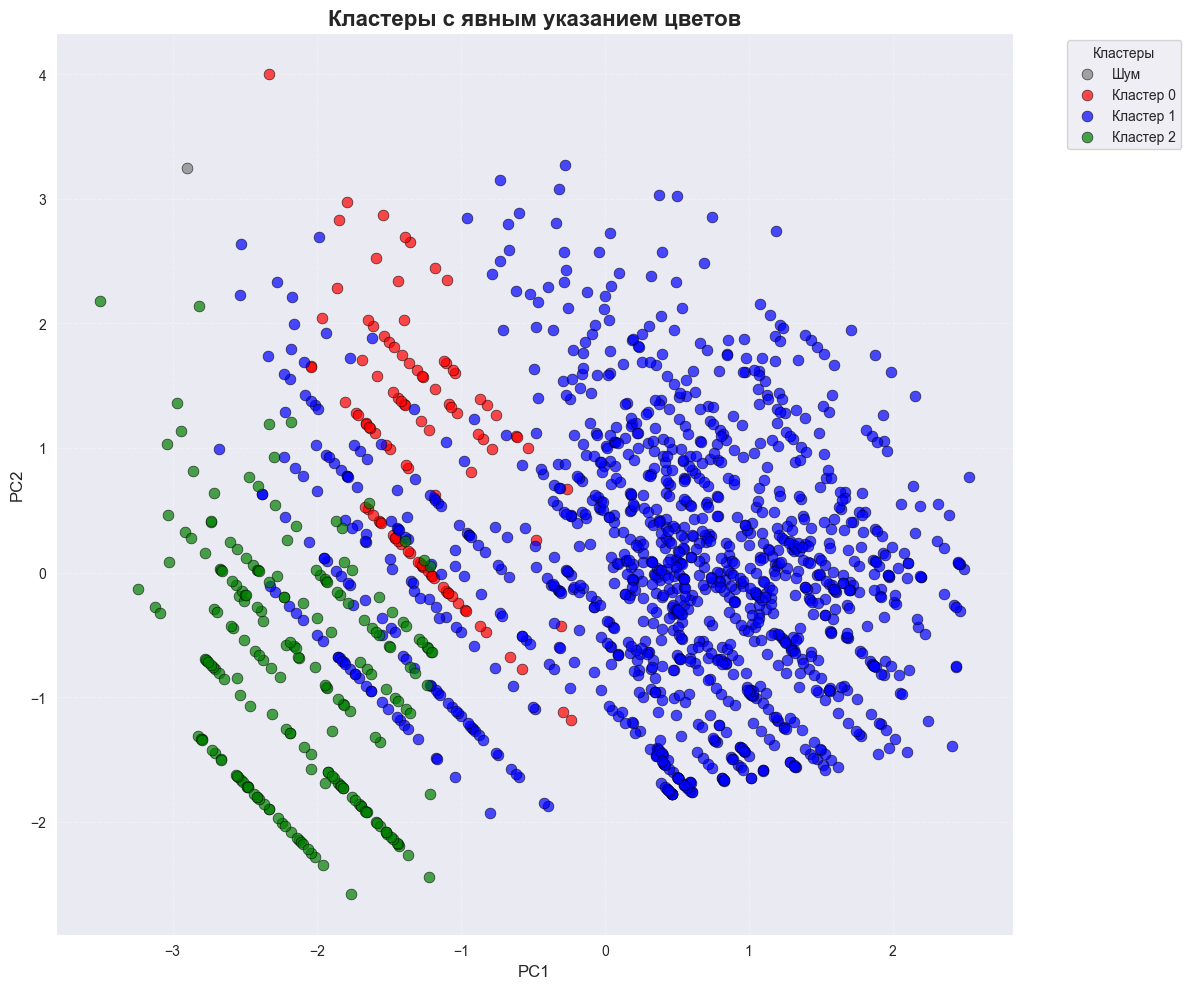

In [46]:
get_scatter(X_pca, labels)

Диаграмма рассеивания аналогично DBSCAN